# FedCare — EDA: CDC Diabetes Health Indicators

Sanity-checks the dataset before any FL/DP code is introduced: shape, missing values, class balance, and feature distributions.

In [1]:
import sys
sys.path.insert(0, '..')

import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from data.loaders import load_diabetes_data, TARGET_COL

RESULTS_DIR = Path('../results')
RESULTS_DIR.mkdir(exist_ok=True)

df = load_diabetes_data()
df.shape

(253680, 22)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-null  int64


In [3]:
# Missing values — expect none; the UCI cleaned BRFSS extract has no nulls
df.isnull().sum().sum()

np.int64(0)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
HighBP,253680.0,0.429001,0.494934,0.0,0.0,0.0,1.0,1.0
HighChol,253680.0,0.424121,0.494210,0.0,0.0,0.0,1.0,1.0
CholCheck,253680.0,0.962670,0.189571,0.0,1.0,1.0,1.0,1.0
BMI,253680.0,28.382364,6.608694,12.0,24.0,27.0,31.0,98.0
Smoker,253680.0,0.443169,0.496761,0.0,0.0,0.0,1.0,1.0
Stroke,253680.0,0.040571,0.197294,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,253680.0,0.094186,0.292087,0.0,0.0,0.0,0.0,1.0
PhysActivity,253680.0,0.756544,0.429169,0.0,1.0,1.0,1.0,1.0
Fruits,253680.0,0.634256,0.481639,0.0,0.0,1.0,1.0,1.0
Veggies,253680.0,0.811420,0.391175,0.0,1.0,1.0,1.0,1.0


## Class balance

Matters for two reasons: (1) it sets what "baseline accuracy" even means (a trivial always-predict-0 classifier already scores ~86%, so accuracy alone is a weak metric — track F1/AUC too), and (2) skew here compounds with the Dirichlet non-IID skew added later, so it's worth seeing the un-partitioned baseline first.

Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64
Diabetes_binary
0    86.1
1    13.9
Name: count, dtype: float64


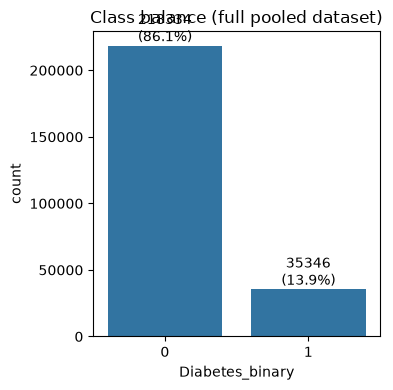

In [5]:
counts = df[TARGET_COL].value_counts().sort_index()
pct = (counts / counts.sum() * 100).round(1)
print(counts)
print(pct)

fig, ax = plt.subplots(figsize=(4, 4))
sns.barplot(x=counts.index.astype(str), y=counts.values, ax=ax)
ax.set_xlabel('Diabetes_binary')
ax.set_ylabel('count')
ax.set_title('Class balance (full pooled dataset)')
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v}\n({pct.iloc[i]}%)', ha='center', va='bottom')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'eda_class_balance.png', dpi=150)
plt.show()

## Feature correlation with target

Quick check that the known clinical risk factors (BMI, HighBP, HighChol, Age, GenHlth) actually correlate with the target in the expected direction — a cheap way to catch a data-loading bug before it costs a week.

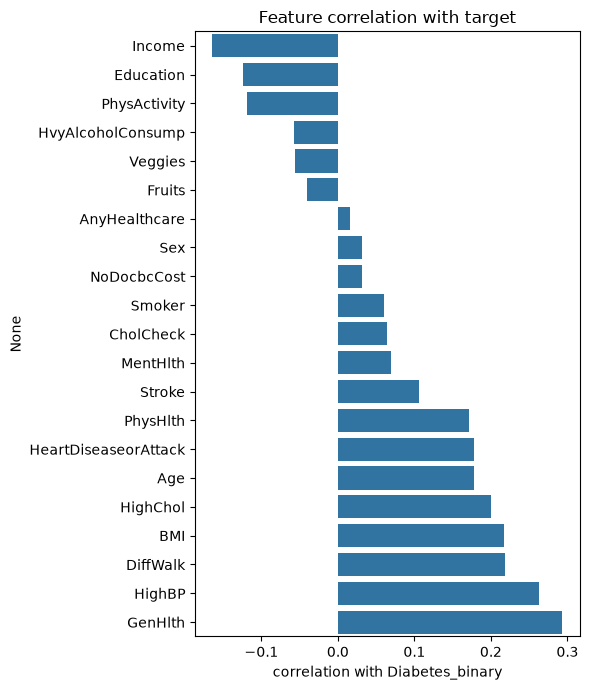

In [6]:
corr = df.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).sort_values()

fig, ax = plt.subplots(figsize=(6, 7))
sns.barplot(x=corr.values, y=corr.index, ax=ax, orient='h')
ax.set_xlabel(f'correlation with {TARGET_COL}')
ax.set_title('Feature correlation with target')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'eda_feature_correlation.png', dpi=150)
plt.show()

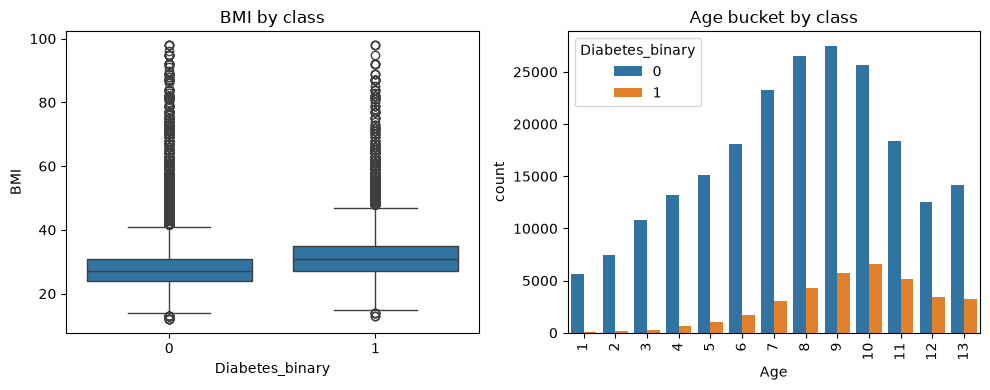

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x=TARGET_COL, y='BMI', ax=axes[0])
axes[0].set_title('BMI by class')
sns.countplot(data=df, x='Age', hue=TARGET_COL, ax=axes[1])
axes[1].set_title('Age bucket by class')
axes[1].tick_params(axis='x', rotation=90)
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'eda_bmi_age.png', dpi=150)
plt.show()

## Non-IID partitioning (Dirichlet)

Simulates 5 hospital clients with different patient populations by splitting the pooled dataset via a Dirichlet draw over the label (Hsu et al., 2019). Low alpha -> highly skewed clients (some see almost only one class); high alpha -> near-IID. This is the standard, citable way to simulate "different hospitals have different patient populations" without a literal hospital-ID column.

In [8]:
from data.partition import dirichlet_partition, client_label_distribution

NUM_CLIENTS = 5
ALPHAS = [0.1, 1.0, 100.0]

y = df[TARGET_COL]
partitions = {alpha: dirichlet_partition(y, NUM_CLIENTS, alpha, seed=42) for alpha in ALPHAS}
for alpha, parts in partitions.items():
    sizes = [len(p) for p in parts]
    print(f'alpha={alpha}: client sizes = {sizes}')

alpha=0.1: client sizes = [75178, 133648, 1864, 4, 42986]
alpha=1.0: client sizes = [82489, 60402, 37434, 16279, 57076]
alpha=100.0: client sizes = [44500, 55573, 46211, 63281, 44115]


Note the alpha=0.1 case: client sizes are wildly unequal (one client can end up with only a handful of rows). This is exactly the risk the plan flags — "Dirichlet alpha too extreme -> FedAvg fails to converge at all" — so alpha=0.1 is a stress-test value, not necessarily what we'll train with by default; alpha will be tuned empirically once federated training is in place.

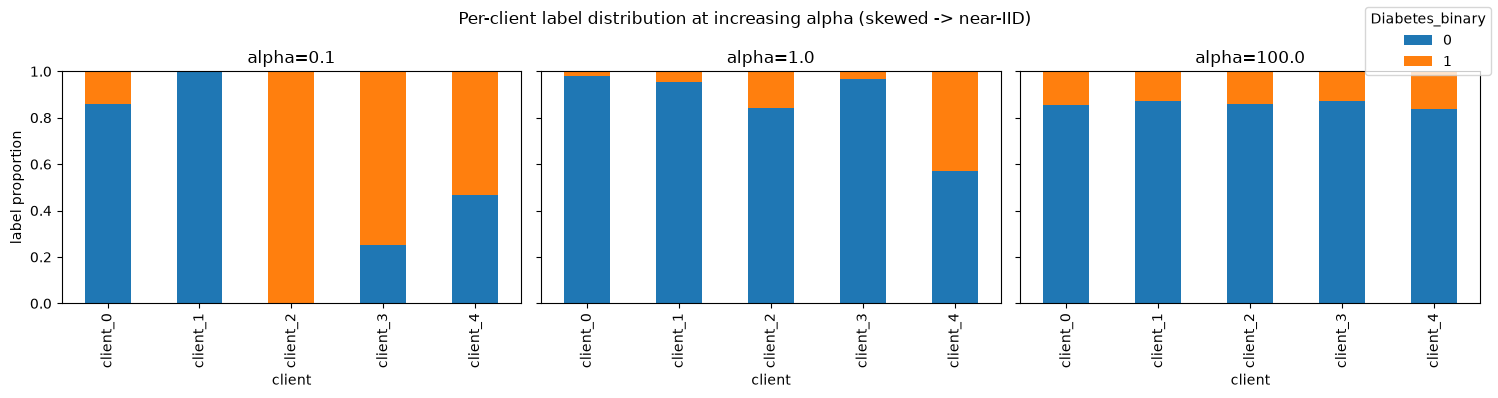

In [9]:
fig, axes = plt.subplots(1, len(ALPHAS), figsize=(5 * len(ALPHAS), 4), sharey=True)
for ax, alpha in zip(axes, ALPHAS):
    dist = client_label_distribution(y, partitions[alpha])
    frac = dist.div(dist.sum(axis=1), axis=0)
    frac.plot(kind='bar', stacked=True, ax=ax, legend=False)
    ax.set_title(f'alpha={alpha}')
    ax.set_xlabel('client')
    ax.set_ylabel('label proportion')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title=TARGET_COL, loc='upper right')
fig.suptitle('Per-client label distribution at increasing alpha (skewed -> near-IID)')
fig.tight_layout()
fig.savefig(RESULTS_DIR / 'eda_dirichlet_partition.png', dpi=150)
plt.show()

## Summary

- 253,680 rows, 21 features, binary target `Diabetes_binary` — matches the plan's expected shape.
- No missing values.
- Target is imbalanced (~86% / ~14%) — baseline and FL evaluation should report F1/AUC and worst-class recall alongside accuracy, not accuracy alone.
- BMI, HighBP, HighChol, GenHlth, Age correlate with the target in the clinically expected direction — no data-loading bug.
- All features are already numeric/ordinal-encoded (no free text, no categorical strings) — minimal preprocessing needed before the MLP baseline.
- At alpha=0.1, per-client sample sizes are wildly unequal (some clients get only a handful of rows) — confirms this is a genuine stress case for FL convergence, not a free parameter to set carelessly.